# Fine-Tuned BERT Phishing Classifier — Final Test Report

This notebook loads a fine-tuned BERT model and evaluates it on a held-out test set.
Outputs include: Accuracy, ROC-AUC, classification report, confusion matrix, and brief error analysis.

### Imports

In [1]:
import os
import random
import evaluate
import torch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from datasets import Dataset,DatasetDict
from pathlib import Path

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)



### Reproducibility + device

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3080


### Load + split data

In [3]:
# Load and Split Data
data_df = pd.read_csv('Phishing_Email.csv')
train_size = .8
validation_size = .1
test_size = .1

# Uses global Seed for random_state
train_df, temp_df = train_test_split(data_df, train_size = train_size, random_state= SEED)
validation_df, test_df = train_test_split(temp_df, test_size=.5, random_state= SEED)

# Configure Pandas Display
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 70)
pd.set_option('display.expand_frame_rep', False)


print("Training Data shape:", train_df.shape)
print("Validation Data shape:", validation_df.shape)
print("Testing Data shape:", test_df.shape)
print()
print("Below is a small sample of what the data we will be using looks like:")

sample_phishing = train_df[train_df['Email Type'] == 'Phishing Email'].sample(n=3, random_state=SEED)
sample_safe = train_df[train_df['Email Type'] == 'Safe Email'].sample(n=3, random_state=SEED)

print(pd.concat([sample_phishing, sample_safe]))

Training Data shape: (14920, 3)
Validation Data shape: (1865, 3)
Testing Data shape: (1865, 3)

Below is a small sample of what the data we will be using looks like:
      Unnamed: 0                                                             Email Text      Email Type
6199        6199  sorry , one more thing cheating adult personals get laid now . rea...  Phishing Email
5658        5658  payment representative dear sir / madam , i am mr . liu peijin , m...  Phishing Email
5466        5466  When Economy goes down, WE go UP !$3000 COMMISSION per Sale for YO...  Phishing Email
7321        7322  fifth annual graduate romanic association at the u . of penn . * *...      Safe Email
3140        3140  december conference preliminary announcement first international w...      Safe Email
3510        3510  re : term project : brian , no problem . vince " brian corbett nel...      Safe Email


### Convert to HuggingFace Datasets

In [4]:
torch.cuda.empty_cache()
print("CPU/GPU Cache Cleared")

train_df["Email Text"] = train_df["Email Text"].fillna("").astype(str)
validation_df["Email Text"] = validation_df["Email Text"].fillna("").astype(str)
test_df["Email Text"] = test_df["Email Text"].fillna("").astype(str)

train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
validation_dataset = Dataset.from_pandas(validation_df, preserve_index=False)
test_dataset = Dataset.from_pandas(test_df, preserve_index=False)

print("Dataset converted to HuggingFace")

CPU/GPU Cache Cleared
Dataset converted to HuggingFace


### Load tokenizer + model

In [5]:
# Base tokenizer (same as training)
model_path = "google-bert/bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_path)

# Paths to saved checkpoints (reuse from test.ipynb)
base_path = os.path.abspath("./BERT/final_phishing_model")

path_v3 = os.path.join(base_path, "checkpoint-2799")

print("Checkpoint v3:", path_v3)

# Load the final checkpoint (v3)
model = AutoModelForSequenceClassification.from_pretrained(path_v3)

print("Loaded fine-tuned BERT model from:", path_v3)

Checkpoint v3: C:\Users\aidan\CS_175\E-ML\BERT\final_phishing_model\checkpoint-2799


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded fine-tuned BERT model from: C:\Users\aidan\CS_175\E-ML\BERT\final_phishing_model\checkpoint-2799


### Preprocess + tokenize

In [6]:
def preprocess_function(examples):
    result = tokenizer(examples["Email Text"], truncation=True, padding=True)

    label_map = {"Safe Email": 0, "Phishing Email": 1}
    result["labels"] = [label_map[l] for l in examples["Email Type"]]

    return result

tokenized_train_data = train_dataset.map(preprocess_function, batched=True)
tokenized_validation_data = validation_dataset.map(preprocess_function, batched=True)
tokenized_test_data = test_dataset.map(preprocess_function, batched=True)

print("Tokenized train/val/test")

Map:   0%|          | 0/14920 [00:00<?, ? examples/s]

Map:   0%|          | 0/1865 [00:00<?, ? examples/s]

Map:   0%|          | 0/1865 [00:00<?, ? examples/s]

Tokenized train/val/test


### Metrics (Accuracy + ROC-AUC)

In [7]:
accuracy = evaluate.load("accuracy")
auc_score = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    probabilities = np.exp(predictions) / np.exp(predictions).sum(-1, keepdims=True)
    positive_class_probs = probabilities[:, 1]

    auc = np.round(
        auc_score.compute(prediction_scores=positive_class_probs, references=labels)["roc_auc"],
        3
    )

    predicted_classes = np.argmax(predictions, axis=1)
    acc = np.round(
        accuracy.compute(predictions=predicted_classes, references=labels)["accuracy"],
        3
    )

    return {"Accuracy": acc, "AUC": auc}

### Data collator

In [8]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("Data collator ready.")

Data collator ready.


### Eval-only TrainingArguments

In [9]:
eval_args = TrainingArguments(
    output_dir="./temp_eval",
    report_to="none"
)

print("Eval args ready.")

Eval args ready.


### Build Trainer

In [10]:
trainer = Trainer(
    model=model,
    args=eval_args,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Trainer ready.")

Trainer ready.


### Evaluate on TEST

In [11]:
test_results = trainer.evaluate(tokenized_test_data)
print("=== FINAL TEST RESULTS ===")
print(test_results)

pred_output = trainer.predict(tokenized_test_data)
y_true = pred_output.label_ids
y_pred = np.argmax(pred_output.predictions, axis=1)

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Safe Email", "Phishing Email"],
    digits=4,
    zero_division=0
))

=== FINAL TEST RESULTS ===
{'eval_loss': 0.06719517707824707, 'eval_model_preparation_time': 0.002, 'eval_Accuracy': 0.981, 'eval_AUC': 0.998, 'eval_runtime': 16.7388, 'eval_samples_per_second': 111.418, 'eval_steps_per_second': 13.98}

=== CLASSIFICATION REPORT ===
                precision    recall  f1-score   support

    Safe Email     0.9876    0.9816    0.9846      1139
Phishing Email     0.9714    0.9807    0.9760       726

      accuracy                         0.9812      1865
     macro avg     0.9795    0.9811    0.9803      1865
  weighted avg     0.9813    0.9812    0.9812      1865



### Confusion Matrix

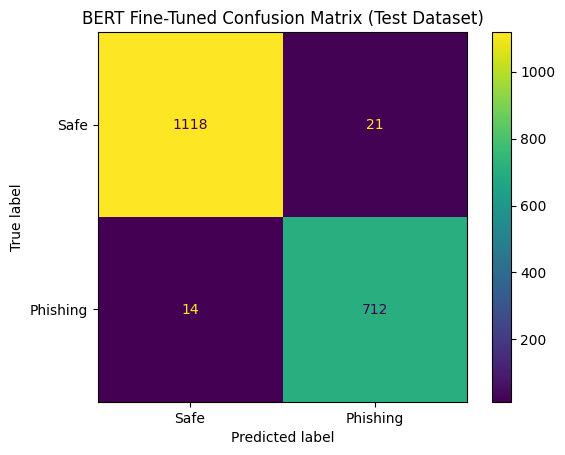

In [12]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Safe", "Phishing"])
disp.plot(values_format="d")
plt.title("BERT Fine-Tuned Confusion Matrix (Test Dataset)")
plt.show()

## Out-of-Distribution Evaluation

This follows the same pattern as the BERT evaluation notebook and uses the same dataset names:
- `CEAS_08.csv`
- `Nigerian_5.csv`
- `Nazario_5.csv`
- `Nazario.csv`
- `SpamAssasin.csv`
- `Nigerian_Fraud.csv`

In [13]:
OOD_DATASETS = [
    ("CEAS_08.csv", "CEAS_08"),
    ("Nigerian_5.csv", "Nigerian_5"),
    ("Nazario_5.csv", "Nazario_5"),
    ("Nazario.csv", "Nazario"),
    ("SpamAssasin.csv", "SpamAssasin"),
    ("Nigerian_Fraud.csv", "Nigerian Fraud"),
]

missing = [path for path, _ in OOD_DATASETS if not Path(path).exists()]
if missing:
    print("Missing OOD files:")
    for item in missing:
        print(" -", item)
    print("\nPlace those CSV files in the same folder as this notebook before running the OOD section.")
else:
    print("All OOD files found.")

All OOD files found.


### OOD Helper

In [20]:
from tqdm.auto import tqdm

def evaluate_dataset_bert(path, title, min_n=50):
    df = pd.read_csv(path)

    # Handle date column if it exists
    has_date = "date" in df.columns
    if has_date:
        df["year"] = pd.to_datetime(df["date"], errors="coerce", utc=True).dt.year.fillna(-1).astype(int)

    # Clean columns
    df["body"] = df["body"].fillna("").astype(str)
    df["label"] = df["label"].astype(int)

    def get_bert_prediction_and_score(text):
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=512
        ).to(model.device)

        with torch.no_grad():
            logits = model(**inputs).logits
            probs = torch.softmax(logits, dim=-1)

        pred = torch.argmax(logits, dim=-1).item()
        phishing_score = probs[0, 1].item()

        return pred, phishing_score

    print(f"Running BERT inference on {title}...")

    preds = []
    scores = []

    for text in tqdm(df["body"], desc=title, leave=True):
        pred, score = get_bert_prediction_and_score(text)
        preds.append(pred)
        scores.append(score)

    df["pred"] = preds
    df["score"] = scores

    print("Inference complete.")

    print(f"\n{'=' * 50}")
    print(f"{title} (BERT Evaluation)")
    print(f"{'=' * 50}")
    print(f"Shape: {df.shape}")

    print(classification_report(
        df["label"],
        df["pred"],
        target_names=["Safe Email", "Phishing Email"],
        digits=4,
        zero_division=0
    ))

    if df["label"].nunique() > 1:
        auc = roc_auc_score(df["label"], df["score"])
        print(f"AUROC: {auc:.4f}")
    else:
        print("AUROC: skipped (only one class present in this dataset)")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    if has_date:
        yr_df = pd.DataFrame([
            {
                "year": y,
                "n": (m := df["year"] == y).sum(),
                "accuracy": accuracy_score(df.loc[m, "label"], df.loc[m, "pred"])
            }
            for y in sorted(df["year"].unique()) if y != -1
        ])

        yr_df = yr_df[yr_df["n"] >= min_n].sort_values("year")

        if not yr_df.empty:
            axes[0].plot(
                yr_df["year"],
                yr_df["accuracy"],
                marker="o",
                linewidth=2,
                markersize=6
            )

            for _, row in yr_df.iterrows():
                axes[0].annotate(
                    f'{row["accuracy"]:.3f}',
                    (row["year"], row["accuracy"]),
                    textcoords="offset points",
                    xytext=(0, 8),
                    ha="center",
                    fontsize=9
                )

            axes[0].set_ylim(0, 1.05)
            axes[0].set_title(f"Accuracy by Year (n ≥ {min_n})", fontsize=13)
            axes[0].set_xlabel("Year", fontsize=11)
            axes[0].set_ylabel("Accuracy", fontsize=11)
            axes[0].set_xticks(yr_df["year"])
            axes[0].tick_params(axis="x", rotation=45, labelsize=10)
            axes[0].tick_params(axis="y", labelsize=10)
            axes[0].grid(True, linestyle="--", alpha=0.4)
        else:
            axes[0].text(0.5, 0.5, "No year groups meet threshold", ha="center", va="center", fontsize=12)
            axes[0].set_title("Accuracy by Year", fontsize=13)
    else:
        axes[0].text(0.5, 0.5, "No date column available", ha="center", va="center", fontsize=12)
        axes[0].set_title("Accuracy by Year", fontsize=13)

    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(df["label"], df["pred"]),
        display_labels=["Safe", "Phishing"]
    ).plot(ax=axes[1], colorbar=False)

    axes[1].set_title(f"Confusion Matrix — {title}", fontsize=13)
    axes[1].tick_params(axis="x", rotation=0, labelsize=10)
    axes[1].tick_params(axis="y", labelsize=10)

    plt.tight_layout(pad=2.0)
    plt.show()

    return df

### BERT on all OOD datasets

Running BERT inference on CEAS_08...


CEAS_08:   0%|          | 0/39154 [00:00<?, ?it/s]

Inference complete.

CEAS_08 (BERT Evaluation)
Shape: (39154, 10)
                precision    recall  f1-score   support

    Safe Email     0.8190    0.9346    0.8730     17312
Phishing Email     0.9416    0.8363    0.8859     21842

      accuracy                         0.8798     39154
     macro avg     0.8803    0.8855    0.8794     39154
  weighted avg     0.8874    0.8798    0.8802     39154

AUROC: 0.9531


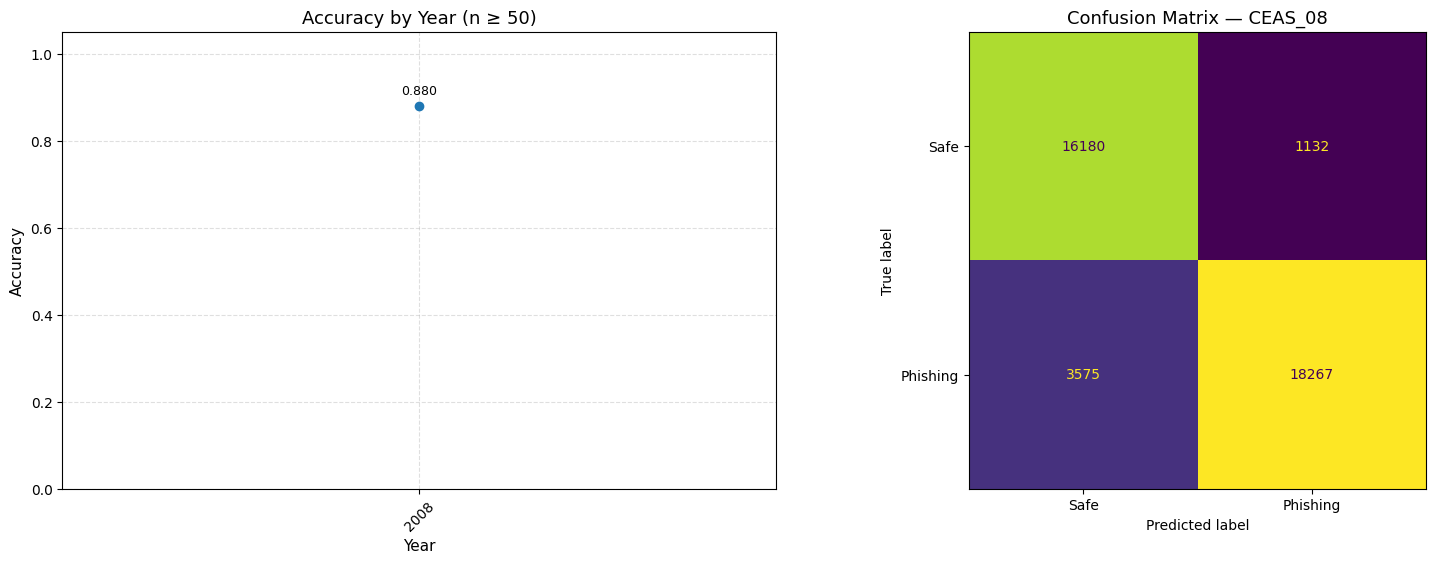

Running BERT inference on Nigerian_5...


Nigerian_5:   0%|          | 0/6331 [00:00<?, ?it/s]

Inference complete.

Nigerian_5 (BERT Evaluation)
Shape: (6331, 10)
                precision    recall  f1-score   support

    Safe Email     0.9910    0.9537    0.9720      2999
Phishing Email     0.9597    0.9922    0.9757      3332

      accuracy                         0.9739      6331
     macro avg     0.9753    0.9729    0.9738      6331
  weighted avg     0.9745    0.9739    0.9739      6331

AUROC: 0.9974


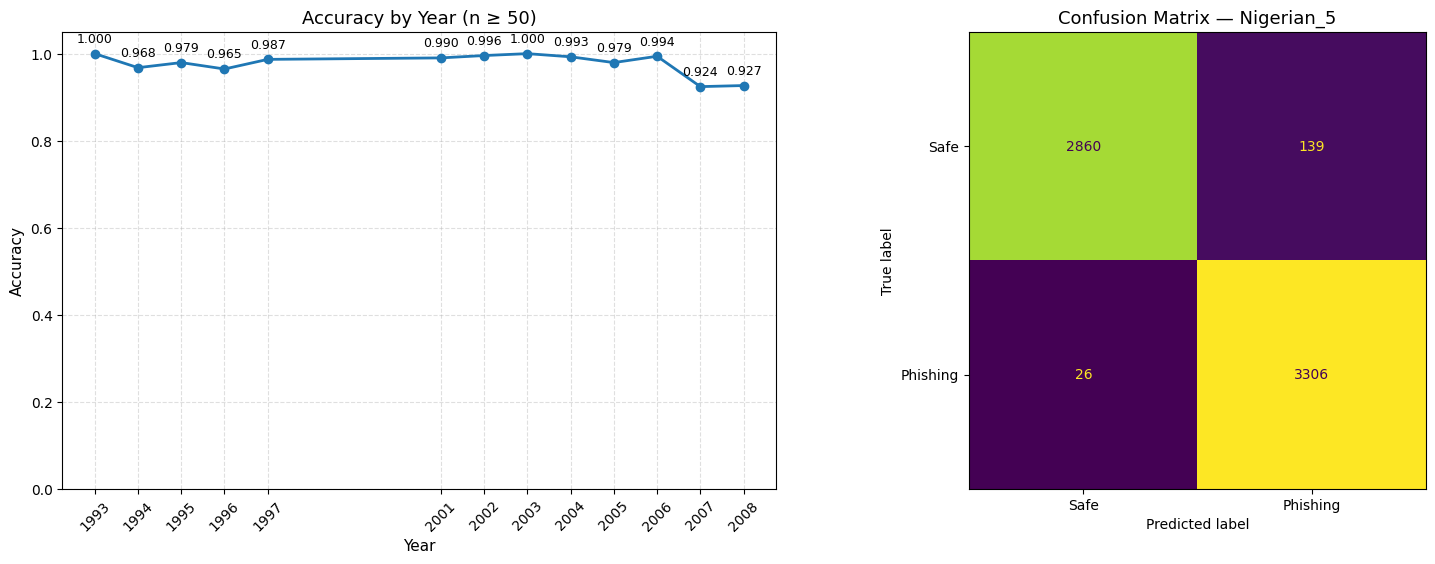

Running BERT inference on Nazario_5...


Nazario_5:   0%|          | 0/3065 [00:00<?, ?it/s]

Inference complete.

Nazario_5 (BERT Evaluation)
Shape: (3065, 10)
                precision    recall  f1-score   support

    Safe Email     0.8083    0.9500    0.8734      1500
Phishing Email     0.9424    0.7840    0.8559      1565

      accuracy                         0.8653      3065
     macro avg     0.8753    0.8670    0.8647      3065
  weighted avg     0.8768    0.8653    0.8645      3065

AUROC: 0.9621


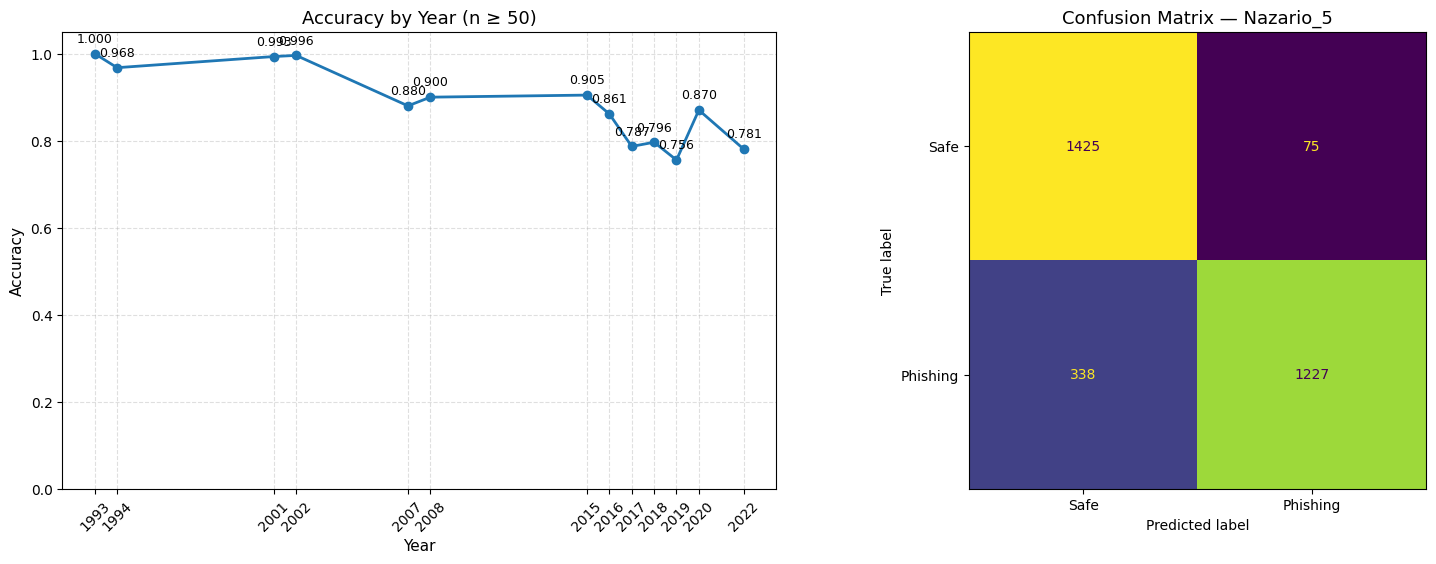

Running BERT inference on Nazario...


Nazario:   0%|          | 0/1565 [00:00<?, ?it/s]

Inference complete.

Nazario (BERT Evaluation)
Shape: (1565, 10)
                precision    recall  f1-score   support

    Safe Email     0.0000    0.0000    0.0000         0
Phishing Email     1.0000    0.7840    0.8789      1565

      accuracy                         0.7840      1565
     macro avg     0.5000    0.3920    0.4395      1565
  weighted avg     1.0000    0.7840    0.8789      1565

AUROC: skipped (only one class present in this dataset)


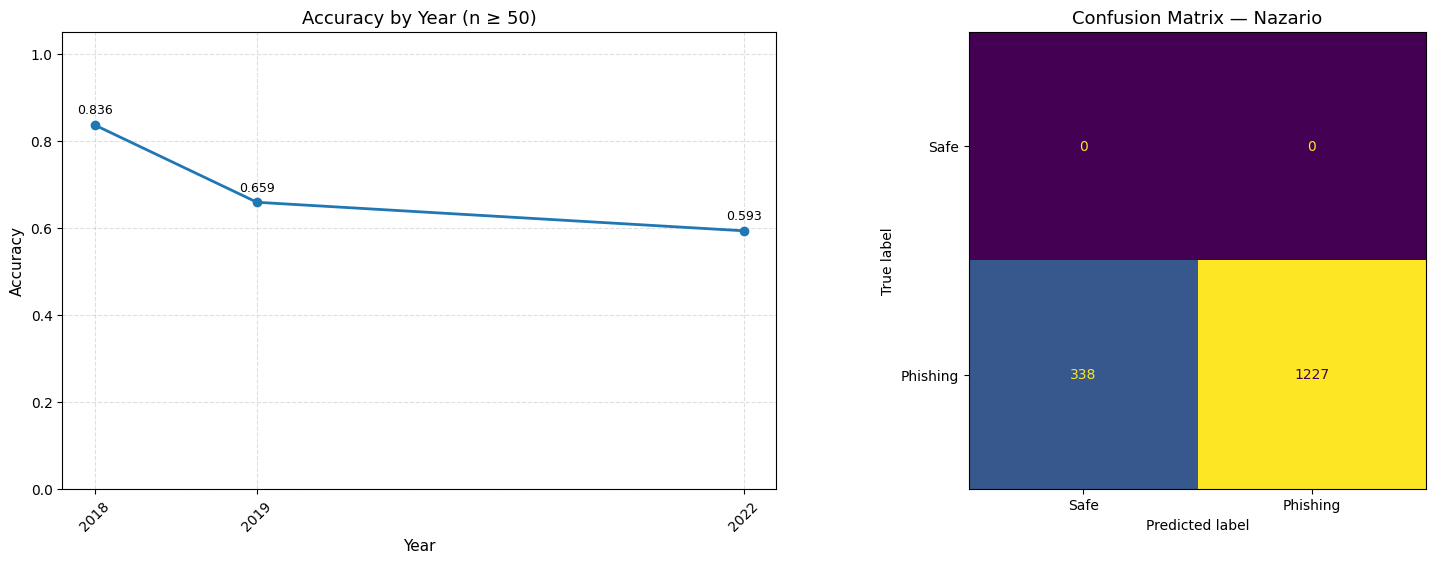

Running BERT inference on SpamAssasin...


SpamAssasin:   0%|          | 0/5809 [00:00<?, ?it/s]

Inference complete.

SpamAssasin (BERT Evaluation)
Shape: (5809, 10)
                precision    recall  f1-score   support

    Safe Email     0.9926    0.9868    0.9897      4091
Phishing Email     0.9690    0.9825    0.9757      1718

      accuracy                         0.9855      5809
     macro avg     0.9808    0.9847    0.9827      5809
  weighted avg     0.9856    0.9855    0.9856      5809

AUROC: 0.9980


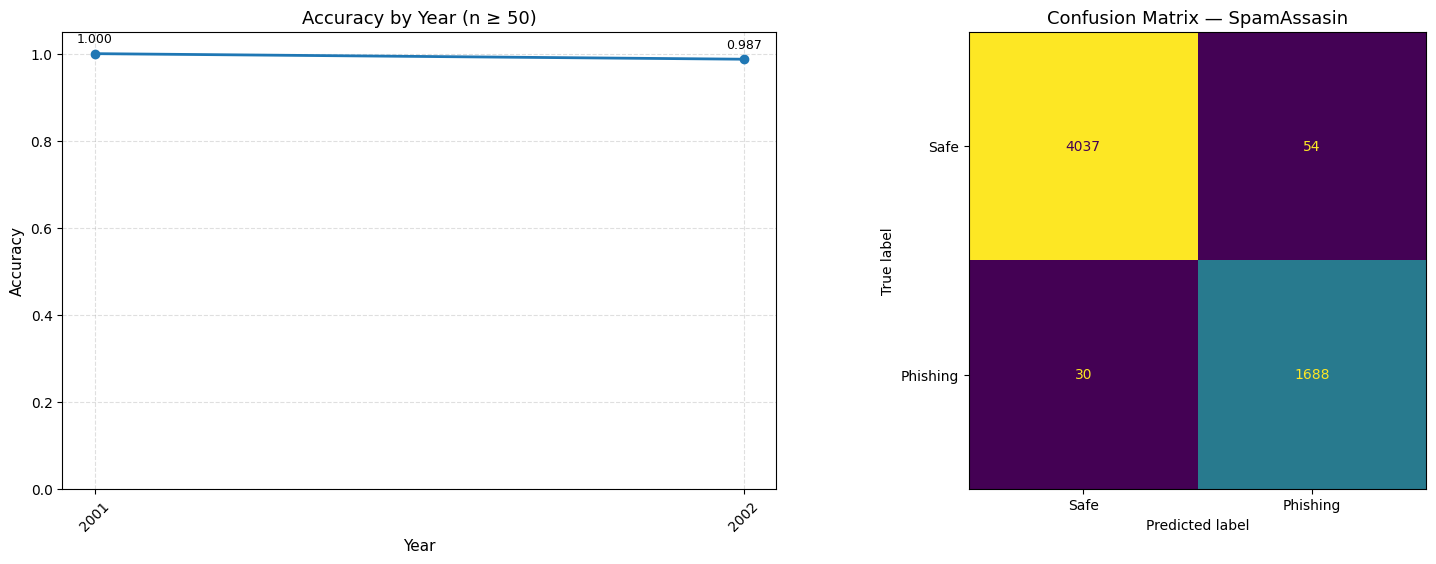

Running BERT inference on Nigerian Fraud...


Nigerian Fraud:   0%|          | 0/3332 [00:00<?, ?it/s]

Inference complete.

Nigerian Fraud (BERT Evaluation)
Shape: (3332, 10)
                precision    recall  f1-score   support

    Safe Email     0.0000    0.0000    0.0000         0
Phishing Email     1.0000    0.9922    0.9961      3332

      accuracy                         0.9922      3332
     macro avg     0.5000    0.4961    0.4980      3332
  weighted avg     1.0000    0.9922    0.9961      3332

AUROC: skipped (only one class present in this dataset)


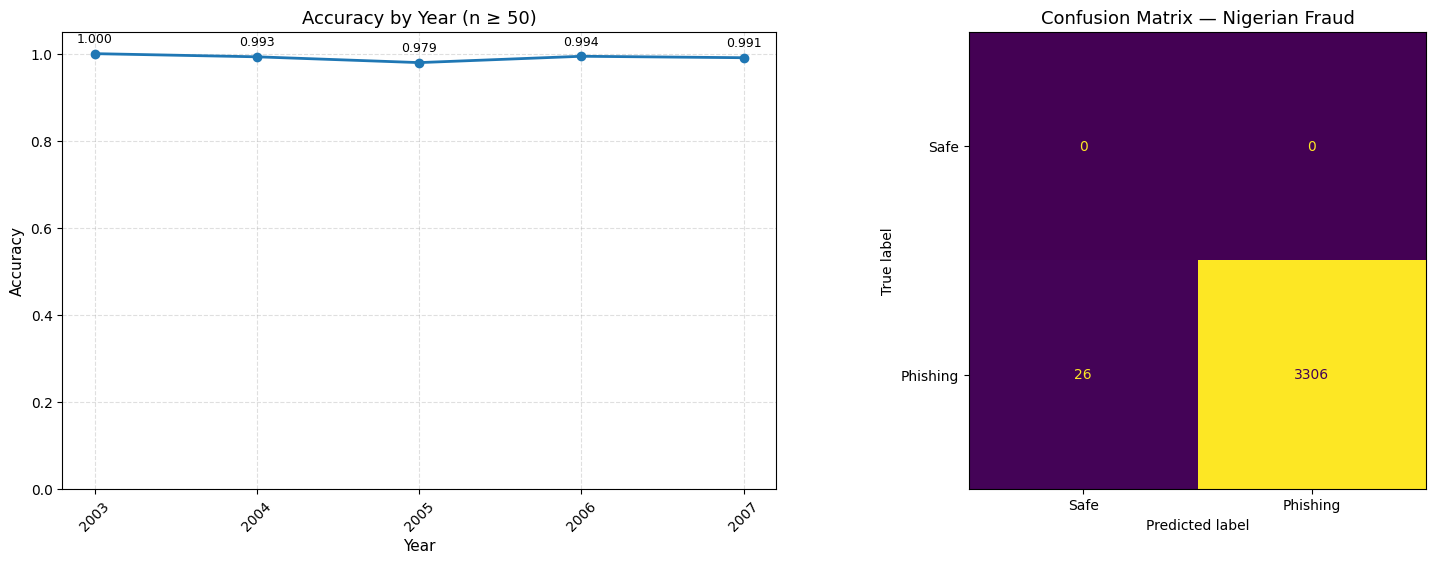

In [21]:
bert_ood_results = {}

for dataset_path, dataset_title in OOD_DATASETS:
    if Path(dataset_path).exists():
        bert_ood_results[dataset_title] = evaluate_dataset_bert(
            path=dataset_path,
            title=dataset_title
        )

### Summary Table

In [22]:
bert_summary_rows = []

for dataset_title, df in bert_ood_results.items():
    bert_summary_rows.append({
        "Model": "BERT",
        "Dataset": dataset_title,
        "Rows": len(df),
        "Accuracy": accuracy_score(df["label"], df["pred"])
    })

bert_summary_df = pd.DataFrame(bert_summary_rows)
display(bert_summary_df.sort_values("Dataset").reset_index(drop=True))

,Model,Dataset,Rows,Accuracy
0,BERT,CEAS_08,39154,0.879782
1,BERT,Nazario,1565,0.784026
2,BERT,Nazario_5,3065,0.865253
3,BERT,Nigerian Fraud,3332,0.992197
4,BERT,Nigerian_5,6331,0.973938
5,BERT,SpamAssasin,5809,0.985540
